In [368]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, filtfilt

Load data

In [369]:
# Load the file
df = pd.read_csv(r"Sivert\Lab 3\Lab 3\Første sett\trans3.txt", sep=r"\s+", header=None)
df.columns = ["Red", "Green", "Blue"]

# Time axis
time = np.linspace(0, 30, len(df))
dt = time[1] - time[0]          # sampling interval
N = len(df)                     # number of samples

TIME DOMAIN PLOT

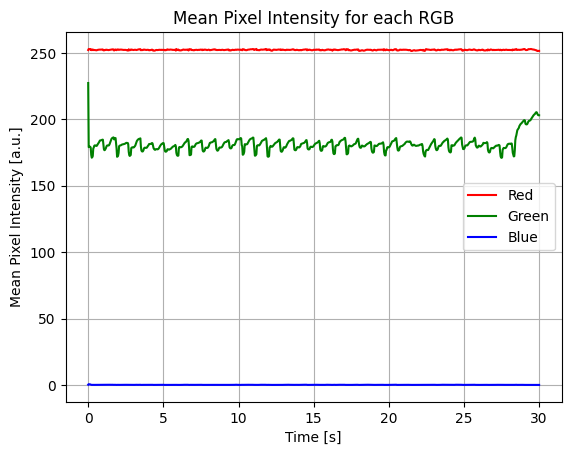

In [370]:
for col in df.columns:
    plt.plot(time, df[col], label=col, color=col[0].lower())

plt.title("Mean Pixel Intensity for each RGB")
plt.xlabel("Time [s]")
plt.ylabel("Mean Pixel Intensity [a.u.]")
#plt.ylim(-0.1,0.6)
plt.legend()
plt.grid(True)
plt.show()

FFT

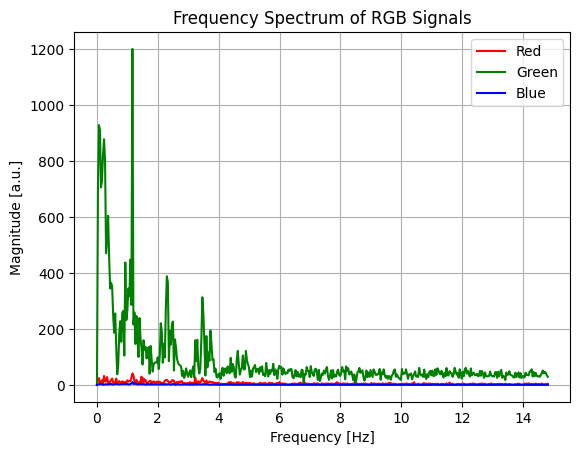

In [391]:
fft_mag_all = []
freqs_all = []
for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)

    fft_vals = np.fft.fft(signal_demeaned)
    freqs = np.fft.fftfreq(N, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])
    fft_mag_all.append(fft_mag)
    freqs_all = freqs_pos

    plt.plot(freqs_pos, fft_mag, label=f"{col}", color=col[0].lower())

plt.legend()    
plt.title("Frequency Spectrum of RGB Signals")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
#plt.xlim(0,4)
#plt.ylim(0,60)
plt.grid(True)
plt.show()

FFT WITH FILTER, ZERO PADDING, AND WINDOWING

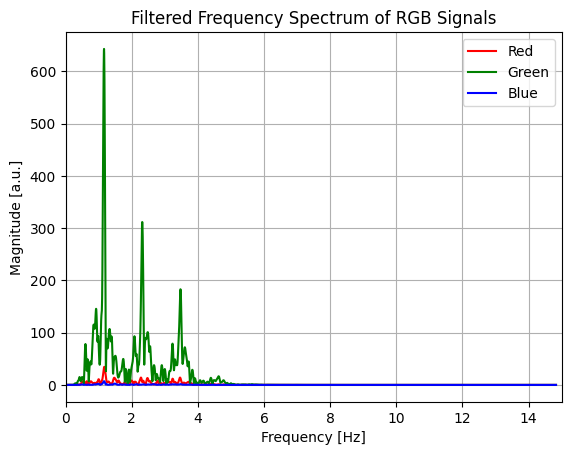

In [392]:
Nfft = N*8
fs = 30
lower_limit = 0.5
upper_limit = 4.0
b, a = butter(3, [lower_limit/(fs/2) , upper_limit/(fs/2)], btype='band')
window = np.hanning(N)

fft_mag_filtered_all = []
freqs_filtered_all = []
for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)
    signal_filtered = filtfilt(b, a, signal_demeaned * window)

    fft_vals = np.fft.fft(signal_filtered, n=Nfft)
    freqs = np.fft.fftfreq(Nfft, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])
    fft_mag_filtered_all.append(fft_mag)
    freqs_filtered_all = freqs_pos

    plt.plot(freqs_pos, fft_mag, label = f"{col}", color=col[0].lower())

plt.legend()    
plt.title("Filtered Frequency Spectrum of RGB Signals")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
plt.xlim(0,15)
#plt.ylim(-5,55)
plt.grid(True)
plt.show()

FIND PULSE

In [373]:
def find_pulsefrequency(magnitude, freq):
    relevant_indices = np.where((freq >= lower_limit) & (freq <= upper_limit))
    relevant_magnitude = magnitude[relevant_indices]
    relevant_freq = freq[relevant_indices]

    if len(relevant_magnitude) == 0:
        return None  # Ingen relevante frekvenser funnet

    max_index = np.argmax(relevant_magnitude)
    pulsefrequency = relevant_freq[max_index]
    
    return freq[np.argmax(magnitude)]
    return pulsefrequency


In [374]:
#--Before filter--
pulsefrequency_red_before = find_pulsefrequency(fft_mag_all[0], freqs_all)
pulsefrequency_green_before = find_pulsefrequency(fft_mag_all[1], freqs_all)
pulsefrequency_blue_before = find_pulsefrequency(fft_mag_all[2], freqs_all)
print(f"Plusefrequency before filter (Red): {pulsefrequency_red_before * 60:.2f} BPM")
print(f"Plusefrequency before filter (Green): {pulsefrequency_green_before * 60:.2f} BPM")
print(f"Plusefrequency before filter (Blue): {pulsefrequency_blue_before * 60:.2f} BPM")

#--After filter--
pulsefrequency_red = find_pulsefrequency(fft_mag_filtered_all[0], freqs_filtered_all)
pulsefrequency_green = find_pulsefrequency(fft_mag_filtered_all[1], freqs_filtered_all)
pulsefrequency_blue = find_pulsefrequency(fft_mag_filtered_all[2], freqs_filtered_all)
print(f"\nPulsefrequency after filter (Red): {pulsefrequency_red * 60:.2f} BPM")
print(f"Pulsefrequency after filter (Green): {pulsefrequency_green * 60:.2f} BPM")
print(f"Pulsefrequency after filter (Blue): {pulsefrequency_blue * 60:.2f} BPM")

Plusefrequency before filter (Red): 69.92 BPM
Plusefrequency before filter (Green): 69.92 BPM
Plusefrequency before filter (Blue): 69.92 BPM

Pulsefrequency after filter (Red): 70.17 BPM
Pulsefrequency after filter (Green): 69.67 BPM
Pulsefrequency after filter (Blue): 69.67 BPM


SNR

In [401]:
Measured_pulse_freq = pulsefrequency_green   # Hz
freq_tolerance = 0.1

#[pulse_frequency - frequency_tolerance, .., .., pulse_frequency + frequency_tolerance]
signal_mask = (freqs_filtered_all >= Measured_pulse_freq - freq_tolerance) & \
              (freqs_filtered_all <= Measured_pulse_freq + freq_tolerance)

harmonic1_mask = (freqs_filtered_all >= 2*Measured_pulse_freq - freq_tolerance) & \
                 (freqs_filtered_all <= 2*Measured_pulse_freq + freq_tolerance)

harmonic2_mask = (freqs_filtered_all >= 3*Measured_pulse_freq - freq_tolerance) & \
                 (freqs_filtered_all <= 3*Measured_pulse_freq + freq_tolerance)

# Noise, everything except signal and harmonics
noise_mask = ~(signal_mask | harmonic1_mask | harmonic2_mask)

power_red_before = (fft_mag_all[0]**2) / N**2
power_green_before = (fft_mag_all[1]**2) / N**2
power_blue_before = (fft_mag_all[2]**2) / N**2

power_red_filtered = (fft_mag_filtered_all[0]**2) / N**2
power_green_filtered = (fft_mag_filtered_all[1]**2) / N**2
power_blue_filtered = (fft_mag_filtered_all[2]**2) / N**2


SNR before filter:
Red: 11.39 dB
Green: 11.75 dB
Blue: 13.51 dB


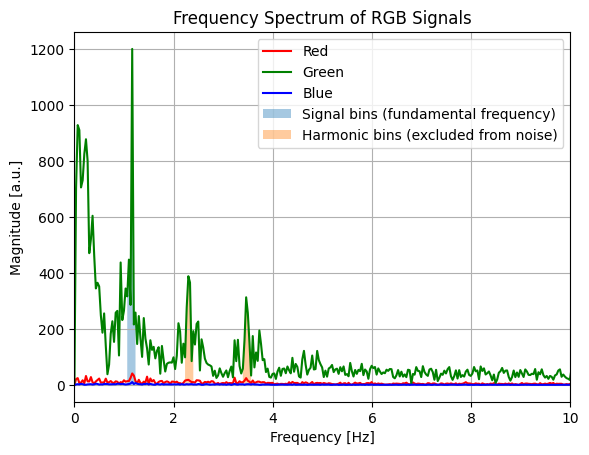

In [ ]:
#---Before filtering--- 
signal_power_red_before = np.mean(power_red_before[signal_mask])
signal_power_green_before = np.mean(power_green_before[signal_mask])
signal_power_blue_before = np.mean(power_blue_before[signal_mask])

noise_power_red_before = np.mean(power_red_before[noise_mask])
noise_power_green_before = np.mean(power_green_before[noise_mask])
noise_power_blue_before = np.mean(power_blue_before[noise_mask])

SNR_red_before = 10 * np.log10(signal_power_red_before / noise_power_red_before)
SNR_green_before = 10 * np.log10(signal_power_green_before / noise_power_green_before)
SNR_blue_before = 10 * np.log10(signal_power_blue_before / noise_power_blue_before)

print("\nSNR before filter:")
print(f"Red: {SNR_red_before:.2f} dB")
print(f"Green: {SNR_green_before:.2f} dB")
print(f"Blue: {SNR_blue_before:.2f} dB")

for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)

    fft_vals = np.fft.fft(signal_demeaned)
    freqs = np.fft.fftfreq(N, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])

    plt.plot(freqs_pos, fft_mag, label=f"{col}", color=col[0].lower())

plt.fill_between(freqs_all, 0, fft_mag_all[1],
                 where=signal_mask, alpha=0.4, label="Signal bins (fundamental frequency)")

plt.fill_between(freqs_all, 0, fft_mag_all[1],
                 where=(harmonic1_mask | harmonic2_mask), alpha=0.4, label="Harmonic bins (excluded from noise)")

plt.xlim(0, 10)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
plt.title("Frequency Spectrum of RGB Signals")
plt.grid(True)
plt.legend()
plt.show()


SNR after filtrering:
Red: 18.17 dB
Green: 23.02 dB
Blue: 19.99 dB


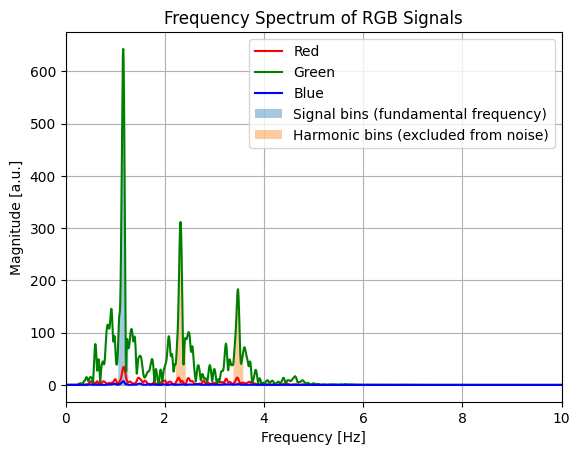

In [404]:
#---After filtering---
signal_power_red_filtered = np.mean(power_red_filtered[signal_mask])
signal_power_green_filtered = np.mean(power_green_filtered[signal_mask])
signal_power_blue_filtered = np.mean(power_blue_filtered[signal_mask])

noise_power_red_filtered = np.mean(power_red_filtered[noise_mask])
noise_power_green_filtered = np.mean(power_green_filtered[noise_mask])
noise_power_blue_filtered = np.mean(power_blue_filtered[noise_mask])

SNR_red_filtered = 10 * np.log10(signal_power_red_filtered / noise_power_red_filtered)
SNR_green_filtered = 10 * np.log10(signal_power_green_filtered / noise_power_green_filtered)
SNR_blue_filtered = 10 * np.log10(signal_power_blue_filtered / noise_power_blue_filtered)

print("\nSNR after filtrering:")
print(f"Red: {SNR_red_filtered:.2f} dB")
print(f"Green: {SNR_green_filtered:.2f} dB")
print(f"Blue: {SNR_blue_filtered:.2f} dB")

for col in df.columns:
    signal = df[col].to_numpy()

    # Remove mean
    signal_demeaned = signal - np.mean(signal)
    signal_filtered = filtfilt(b, a, signal_demeaned * window)

    fft_vals = np.fft.fft(signal_filtered, n=Nfft)
    freqs = np.fft.fftfreq(Nfft, d=dt)

    # Keep only positive frequencies
    mask = (freqs >= 0)
    freqs_pos = freqs[mask]
    fft_mag = np.abs(fft_vals[mask])

    plt.plot(freqs_pos, fft_mag, label = f"{col}", color=col[0].lower())

plt.fill_between(freqs_filtered_all, 0, fft_mag_filtered_all[1],
                 where=signal_mask, alpha=0.4, label="Signal bins (fundamental frequency)")

plt.fill_between(freqs_filtered_all, 0, fft_mag_filtered_all[1],
                 where=(harmonic1_mask | harmonic2_mask), alpha=0.4, label="Harmonic bins (excluded from noise)")

plt.xlim(0, 10)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [a.u.]")
plt.title("Frequency Spectrum of RGB Signals")
plt.grid(True)
plt.legend()
plt.show()

In [378]:
def compute_stats(data):
    mean = np.mean(data)
    variance = np.var(data)
    std_dev = np.sqrt(variance)
    return mean, variance, std_dev

In [379]:
transmittance_red = [71.67, 73.17, 70.17, 68.92, 68.17]
transmittance_green = [71.67, 72.17, 69.67, 68.92, 67.92]
transmittance_blue = [71.92, 73.17,69.67, 69.42, 68.67]

reflectance_red = [61.18, 61.68, 64.68, 65.43, 66.43]
reflectance_green = [57.93, 61.93, 64.43, 65.68, 66.18]
reflectance_blue = [59.18, 62.43, 59.93, 65.68, 65.93]

# Transmittance
mean_trans_red, var_trans_red, std_trans_red = compute_stats(transmittance_red)
mean_trans_green, var_trans_green, std_trans_green = compute_stats(transmittance_green)
mean_trans_blue, var_trans_blue, std_trans_blue = compute_stats(transmittance_blue)

# Reflectance
mean_refl_red, var_refl_red, std_refl_red = compute_stats(reflectance_red)
mean_refl_green, var_refl_green, std_refl_green = compute_stats(reflectance_green)
mean_refl_blue, var_refl_blue, std_refl_blue = compute_stats(reflectance_blue)


print("Transmittance Red Channel")
print(f"Mean: {mean_trans_red:.2f} BPM")
print(f"Variance: {var_trans_red:.4f} (BPM)^2")
print(f"Standard Deviation: {std_trans_red:.2f} BPM\n")


print("Transmittance Green Channel")
print(f"Mean: {mean_trans_green:.2f} BPM")
print(f"Variance: {var_trans_green:.4f} (BPM)^2")
print(f"Standard Deviation: {std_trans_green:.2f} BPM\n")


print("Transmittance Blue Channel")
print(f"Mean: {mean_trans_blue:.2f} BPM")
print(f"Variance: {var_trans_blue:.4f} (BPM)^2")
print(f"Standard Deviation: {std_trans_blue:.2f} BPM\n")


print("\nReflectance Red Channel")
print(f"Mean: {mean_refl_red:.2f} BPM")
print(f"Variance: {var_refl_red:.4f} (BPM)^2")
print(f"Standard Deviation: {std_refl_red:.2f} BPM\n")

print("Reflectance Green Channel")
print(f"Mean: {mean_refl_green:.2f} BPM")
print(f"Variance: {var_refl_green:.4f} (BPM)^2")
print(f"Standard Deviation: {std_refl_green:.2f} BPM\n")

print("Reflectance Blue Channel")
print(f"Mean: {mean_refl_blue:.2f} BPM")
print(f"Variance: {var_refl_blue:.4f} (BPM)^2")
print(f"Standard Deviation: {std_refl_blue:.2f} BPM")

Transmittance Red Channel
Mean: 70.42 BPM
Variance: 3.3000 (BPM)^2
Standard Deviation: 1.82 BPM

Transmittance Green Channel
Mean: 70.07 BPM
Variance: 2.6150 (BPM)^2
Standard Deviation: 1.62 BPM

Transmittance Blue Channel
Mean: 70.57 BPM
Variance: 2.8650 (BPM)^2
Standard Deviation: 1.69 BPM


Reflectance Red Channel
Mean: 63.88 BPM
Variance: 4.3350 (BPM)^2
Standard Deviation: 2.08 BPM

Reflectance Green Channel
Mean: 63.23 BPM
Variance: 9.1850 (BPM)^2
Standard Deviation: 3.03 BPM

Reflectance Blue Channel
Mean: 62.63 BPM
Variance: 7.8850 (BPM)^2
Standard Deviation: 2.81 BPM
